# Credit Card Fraud Detection

The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

# Explor Data

In [1]:
#import libs 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns   

In [2]:
df = pd.read_csv('/mnt/e/Machine Learning/Credit-Card-Fraud-Detection/src/data/split/train.csv')

In [3]:
df.shape

(170884, 31)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170884 entries, 0 to 170883
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    170884 non-null  float64
 1   V1      170884 non-null  float64
 2   V2      170884 non-null  float64
 3   V3      170884 non-null  float64
 4   V4      170884 non-null  float64
 5   V5      170884 non-null  float64
 6   V6      170884 non-null  float64
 7   V7      170884 non-null  float64
 8   V8      170884 non-null  float64
 9   V9      170884 non-null  float64
 10  V10     170884 non-null  float64
 11  V11     170884 non-null  float64
 12  V12     170884 non-null  float64
 13  V13     170884 non-null  float64
 14  V14     170884 non-null  float64
 15  V15     170884 non-null  float64
 16  V16     170884 non-null  float64
 17  V17     170884 non-null  float64
 18  V18     170884 non-null  float64
 19  V19     170884 non-null  float64
 20  V20     170884 non-null  float64
 21  V21     170884 non-nu

In [5]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,119191.0,2.052427,-0.133236,-1.740621,0.277935,0.337999,-0.826933,0.334629,-0.227039,0.267655,...,-0.006518,0.121300,0.037733,-0.356498,0.147822,0.569149,-0.103929,-0.091958,8.73,0
1,71750.0,1.220356,-0.159191,-0.444349,-0.094437,0.104457,-0.345790,0.170867,-0.094996,0.187572,...,-0.088775,-0.364654,-0.140851,-0.707308,0.415661,1.087767,-0.102532,-0.008335,59.95,0
2,151977.0,0.892824,-1.440698,-0.637940,3.912871,0.099291,2.433288,-0.308891,0.603227,-0.113826,...,0.484969,0.487304,-0.122694,-0.598803,-0.594563,0.062841,-0.033426,0.038254,460.65,0
3,55709.0,-3.146021,2.247634,0.901397,0.146162,-2.109360,-0.148312,-1.533191,2.073663,0.499394,...,0.050567,-0.037019,0.107000,0.392857,0.303597,0.379544,-0.148990,0.074965,4.78,0
4,66654.0,1.194996,-0.007495,0.301285,0.750199,-0.297494,-0.405836,0.060410,-0.150482,0.400860,...,-0.234931,-0.545566,-0.089418,-0.064036,0.527305,0.294221,-0.025980,0.015637,44.31,0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,170884.0,94966.107886,47464.723773,0.000000,54348.000000,84923.500000,139404.000000,172792.000000
V1,170884.0,-0.001070,1.958944,-46.855047,-0.922071,0.016603,1.316250,2.451888
V2,170884.0,-0.000904,1.650481,-63.344698,-0.599127,0.065839,0.802518,22.057729
V3,170884.0,-0.002722,1.521820,-48.325589,-0.896376,0.177007,1.028302,4.226108
V4,170884.0,-0.002603,1.416490,-5.683171,-0.848978,-0.020895,0.738812,16.875344
V5,170884.0,0.000151,1.394123,-113.743307,-0.691840,-0.054185,0.612154,34.099309
V6,170884.0,0.000779,1.338331,-23.496714,-0.768986,-0.274228,0.400359,73.301626
V7,170884.0,-0.000811,1.260122,-43.557242,-0.554440,0.040417,0.569221,120.589494
V8,170884.0,-0.002327,1.208709,-73.216718,-0.209596,0.021461,0.326026,18.282168
V9,170884.0,-0.000622,1.098393,-13.434066,-0.642036,-0.051777,0.595095,10.392889


we can see all (V) feats normal  

Time and Amount have high std we should normalize it 

we can use: 
      
        log-transformation   Stander Scaler  Min max Scaler 
         

# Check missing values

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# check dublicate

In [8]:
df.duplicated().sum()

np.int64(448)

we have some dublicate raws i prefer to delete them

In [9]:
df.drop_duplicates()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,119191.0,2.052427,-0.133236,-1.740621,0.277935,0.337999,-0.826933,0.334629,-0.227039,0.267655,...,-0.006518,0.121300,0.037733,-0.356498,0.147822,0.569149,-0.103929,-0.091958,8.73,0
1,71750.0,1.220356,-0.159191,-0.444349,-0.094437,0.104457,-0.345790,0.170867,-0.094996,0.187572,...,-0.088775,-0.364654,-0.140851,-0.707308,0.415661,1.087767,-0.102532,-0.008335,59.95,0
2,151977.0,0.892824,-1.440698,-0.637940,3.912871,0.099291,2.433288,-0.308891,0.603227,-0.113826,...,0.484969,0.487304,-0.122694,-0.598803,-0.594563,0.062841,-0.033426,0.038254,460.65,0
3,55709.0,-3.146021,2.247634,0.901397,0.146162,-2.109360,-0.148312,-1.533191,2.073663,0.499394,...,0.050567,-0.037019,0.107000,0.392857,0.303597,0.379544,-0.148990,0.074965,4.78,0
4,66654.0,1.194996,-0.007495,0.301285,0.750199,-0.297494,-0.405836,0.060410,-0.150482,0.400860,...,-0.234931,-0.545566,-0.089418,-0.064036,0.527305,0.294221,-0.025980,0.015637,44.31,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170879,137874.0,-2.314356,-1.477150,1.847313,-0.171896,0.929503,0.331769,-0.180278,0.296973,0.167303,...,0.130012,0.319415,0.328271,0.300380,0.608955,-0.230660,-0.040699,0.266017,182.88,0
170880,6559.0,-1.775889,-0.059785,2.371322,-2.628981,0.151867,-0.650695,-0.433332,0.027177,3.370020,...,-0.097743,0.610452,-0.577917,-0.282703,0.442635,0.007669,0.455482,0.013437,14.00,0
170881,159020.0,1.879717,-0.557359,-0.426212,-0.041480,-0.240394,0.650912,-0.818833,0.401973,1.405719,...,-0.072211,-0.025659,0.489627,-1.090862,-0.781050,-0.166246,0.055082,-0.050150,1.00,0
170882,34859.0,0.879168,-0.494534,0.921462,1.565359,-0.967113,0.040689,-0.338960,0.180871,1.020498,...,0.060998,0.193461,-0.130303,0.411289,0.476105,-0.275632,0.045707,0.044743,123.50,0


# investgate Time and Amount

In [10]:
#helper functions  

def remove_outliers_iqr(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Removes rows containing outliers in the specified columns using the IQR method.

    Parameters:
    - df: Input pandas DataFrame
    - columns: List of numerical column names to filter

    Returns:
    - Cleaned pandas DataFrame
    """
    df_clean = df.copy()
    for col in columns:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        df_clean = df_clean[
            (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
        ]

    return df_clean 





def clip_outliers_iqr(
    df: pd.DataFrame, columns: list[str], factor: float = 1.5
) -> pd.DataFrame:
    """Clips (caps) extreme values in specified columns using IQR bounds.

    Parameters:
    - df: Input pandas DataFrame
    - columns: List of numerical column names to process
    - factor: IQR multiplier for outlier boundaries (default is 1.5)

    Returns:
    - Modified pandas DataFrame with clipped features
    """
    df_clipped = df.copy()

    for col in columns:
        q1 = df_clipped[col].quantile(0.25)
        q3 = df_clipped[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - factor * iqr
        upper_bound = q3 + factor * iqr

        # Clip values below lower_bound to lower_bound, and above upper_bound to upper_bound
        df_clipped[col] = df_clipped[col].clip(
            lower=lower_bound, upper=upper_bound
        )

    return df_clipped 





def plot_distributions(
    df: pd.DataFrame,
    columns: list[str],
    bins: int = 30,
    figsize_per_row: tuple[int, int] = (12, 3),
) -> None:
    """Plots histograms with KDE overlay and box plots for specified numerical columns.

    Parameters:
    - df: Input pandas DataFrame
    - columns: List of numerical column names to plot
    - bins: Number of histogram bins
    - figsize_per_row: Tuple controlling width and height per feature plot
    """
    sns.set_theme(style="whitegrid")
    n_cols = len(columns)

    if n_cols == 0:
        print("No columns provided to plot.")
        return

    # Create a figure with 2 subplots per feature (Histogram + Boxplot)
    fig, axes = plt.subplots(
        nrows=n_cols,
        ncols=2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * n_cols),
        gridspec_kw={"width_ratios": [3, 1]},
    )

    # Ensure axes is 2D array even for a single column
    if n_cols == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, col in enumerate(columns):
        # 1. Histogram + KDE
        sns.histplot(
            data=df,
            x=col,
            kde=True,
            bins=bins,
            ax=axes[i, 0],
            color="skyblue",
            edgecolor="black",
        )
        axes[i, 0].set_title(f"Distribution: {col}", fontsize=12, weight="bold")
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel("Count")

        # 2. Boxplot (to visually identify outliers)
        sns.boxplot(
            data=df, x=col, ax=axes[i, 1], color="salmon", fliersize=3
        )
        axes[i, 1].set_title(f"Box Plot: {col}", fontsize=12, weight="bold")
        axes[i, 1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

In [11]:
df['Time'].describe()

count    170884.000000
mean      94966.107886
std       47464.723773
min           0.000000
25%       54348.000000
50%       84923.500000
75%      139404.000000
max      172792.000000
Name: Time, dtype: float64

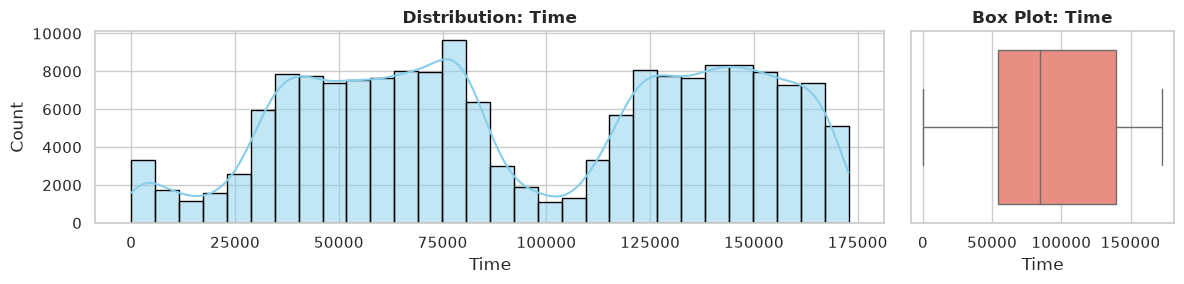

In [12]:
plot_distributions(df,['Time'])

from this figur we have complex distribution function to time 

In [13]:
df['log_time'] = np.log1p(df['Time'])

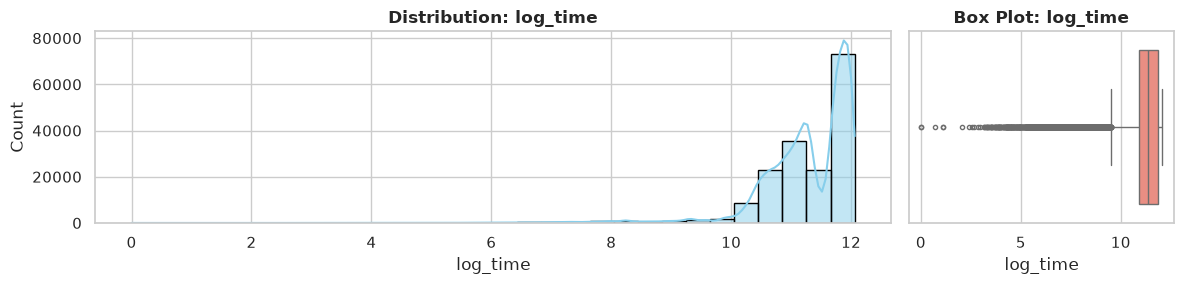

In [14]:
plot_distributions(df, ['log_time'])

In [15]:
df['log_time'].std()

np.float64(0.8155709504098214)

Time have some outliers we must cliping it

In [16]:
df['Amount'].describe()

count    170884.000000
mean         88.511723
std         256.737144
min           0.000000
25%           5.637500
50%          22.020000
75%          77.650000
max       25691.160000
Name: Amount, dtype: float64

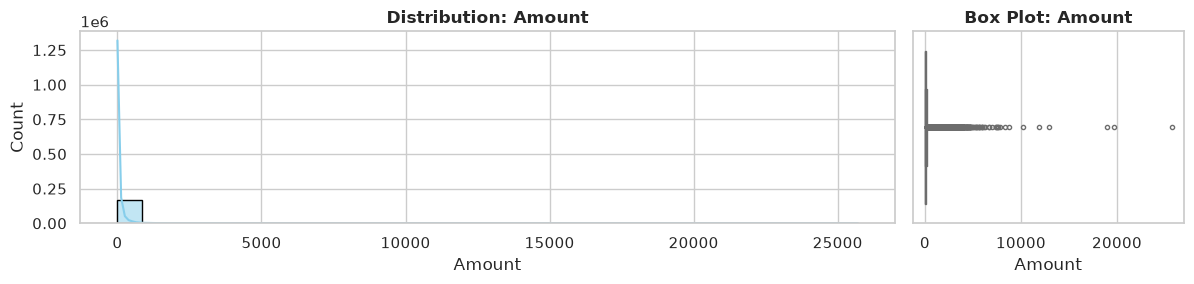

In [17]:
plot_distributions(df, ['Amount'])

Amount have some outliers we should clip it 

Amount have high std i will apply log transform

In [18]:
df['log_amount'] = np.log1p(df['Amount'])

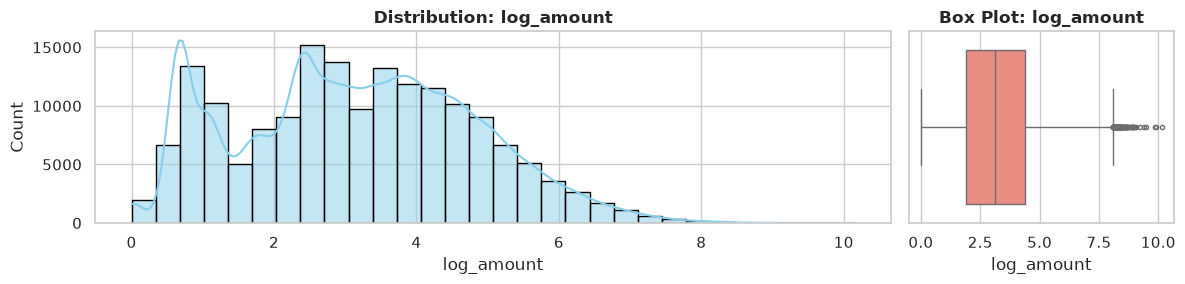

In [19]:
plot_distributions(df, ['log_amount'])

after log we have good distribution but still have outliers

# Target Analysis

In [20]:
df['Class'].describe()

count    170884.000000
mean          0.001785
std           0.042210
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Class, dtype: float64

   Class     ratio   count
0      0  0.998215  170579
1      1  0.001785     305


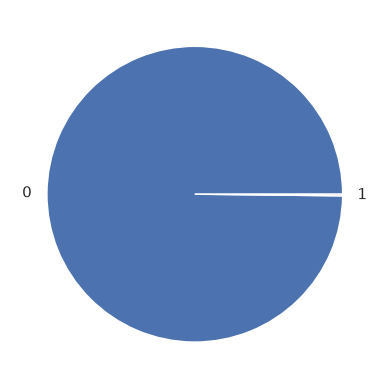

In [29]:
# check class imbalance
num_rows = df.shape[0]
class_count = df["Class"].value_counts().to_dict()

class_stat = pd.DataFrame({
    "Class": class_count.keys(),
    "ratio": [i / num_rows for i in class_count.values()],
    "count": class_count.values()
})

print(class_stat)
df["Class"].value_counts().plot(kind="pie")
plt.show()

we have high impalance in data 

we can solve this using: 

    oversmpling 
    undersmpling
    class wights    

In [22]:
from sklearn.manifold import TSNE 
def visualize(X, y): 
    tsne = TSNE(n_components=2) 
    x_embeded = tsne.fit_transform(X) 
    plt.scatter(x_embeded[:, 0], x_embeded[:, 1], c=y)
    plt.colorbar() 
    plt.show()

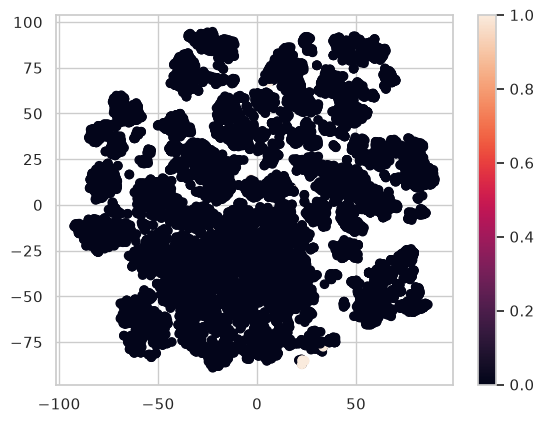

In [23]:
from sklearn.model_selection import train_test_split

# Create a 5,000-row sample that preserves the exact 'Class' proportions
df_sampled, _ = train_test_split(
    df, 
    train_size=15000, 
    stratify=df['Class'], 
    random_state=42
)

X_sample = df_sampled.drop(['Class', 'Time', 'Amount'], axis=1)
y_sample = df_sampled['Class']

# Now run your t-SNE function
visualize(X_sample, y_sample)

from this diagram we can see postive class is vere small and distancate we can not use oversampling this be misleading 

In [24]:
df_posc = df[df['Class'] == 1] 
df_posc.shape

(305, 33)

In [25]:
df_negc = df[df['Class']==0] 
df_negc.shape

(170579, 33)

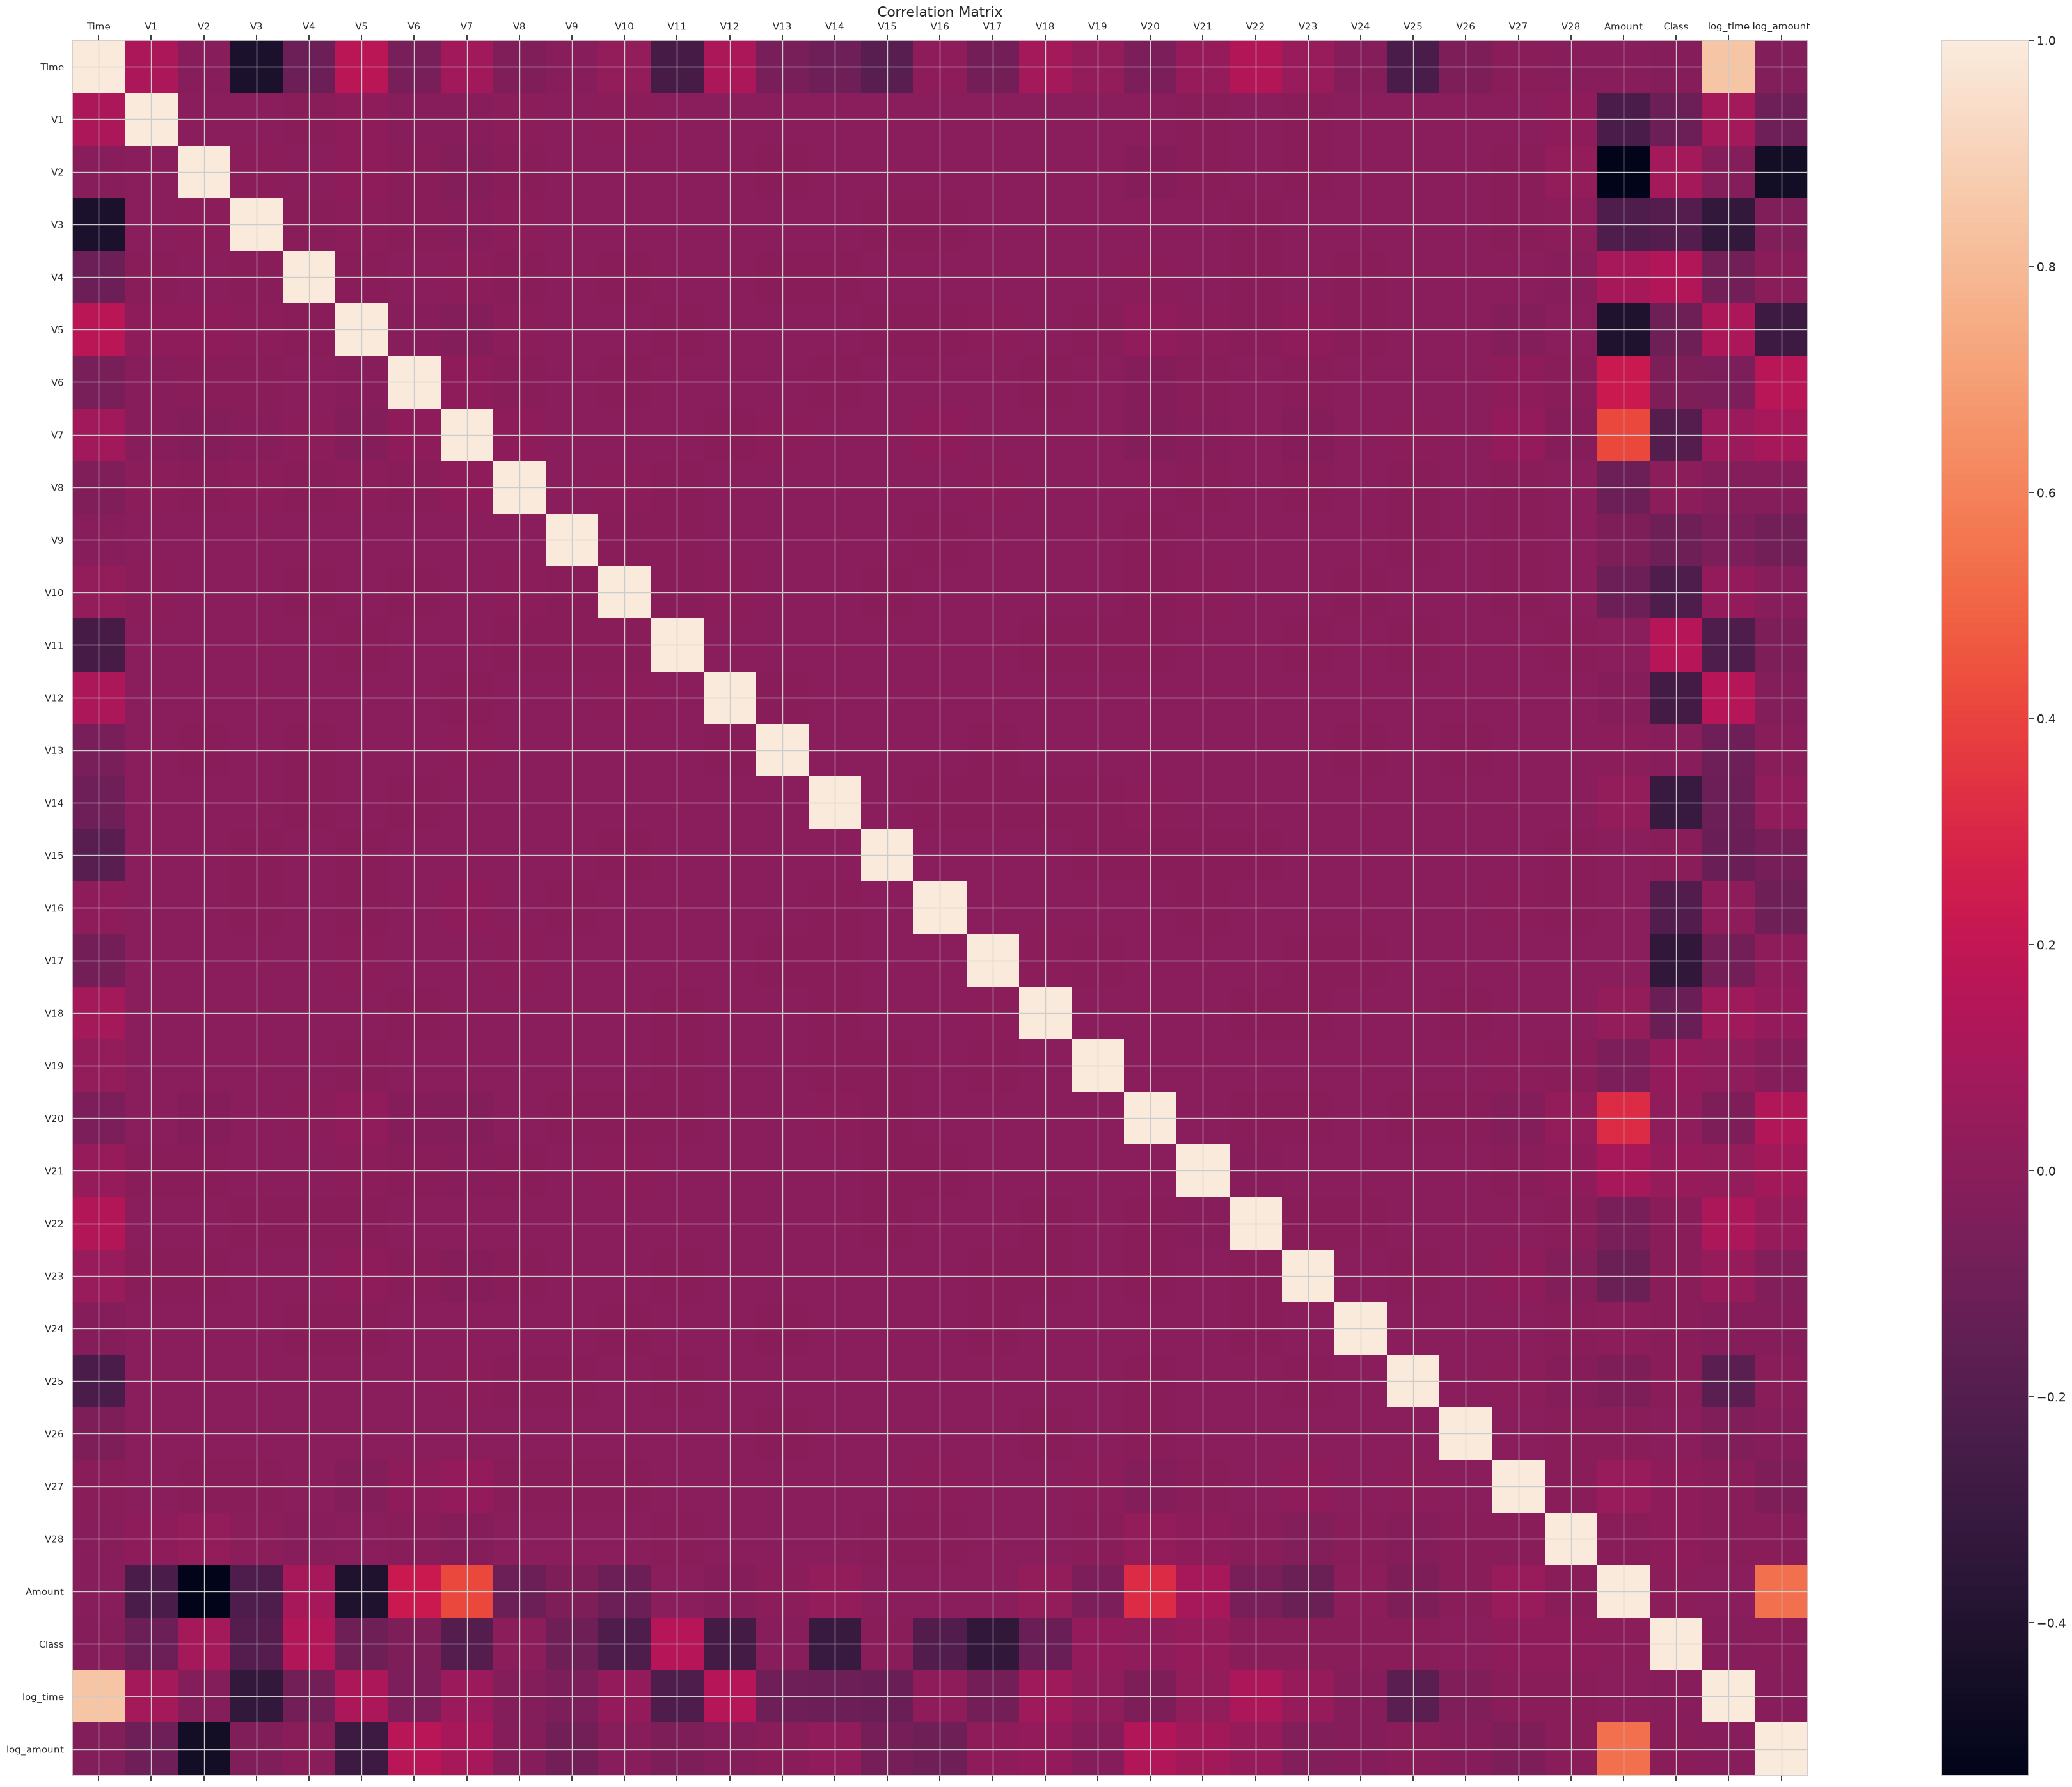

In [37]:
# plot correlation matrix
corr = df.corr()
f = plt.figure(figsize=(54, 35))
plt.matshow(corr, fignum=f.number)
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);

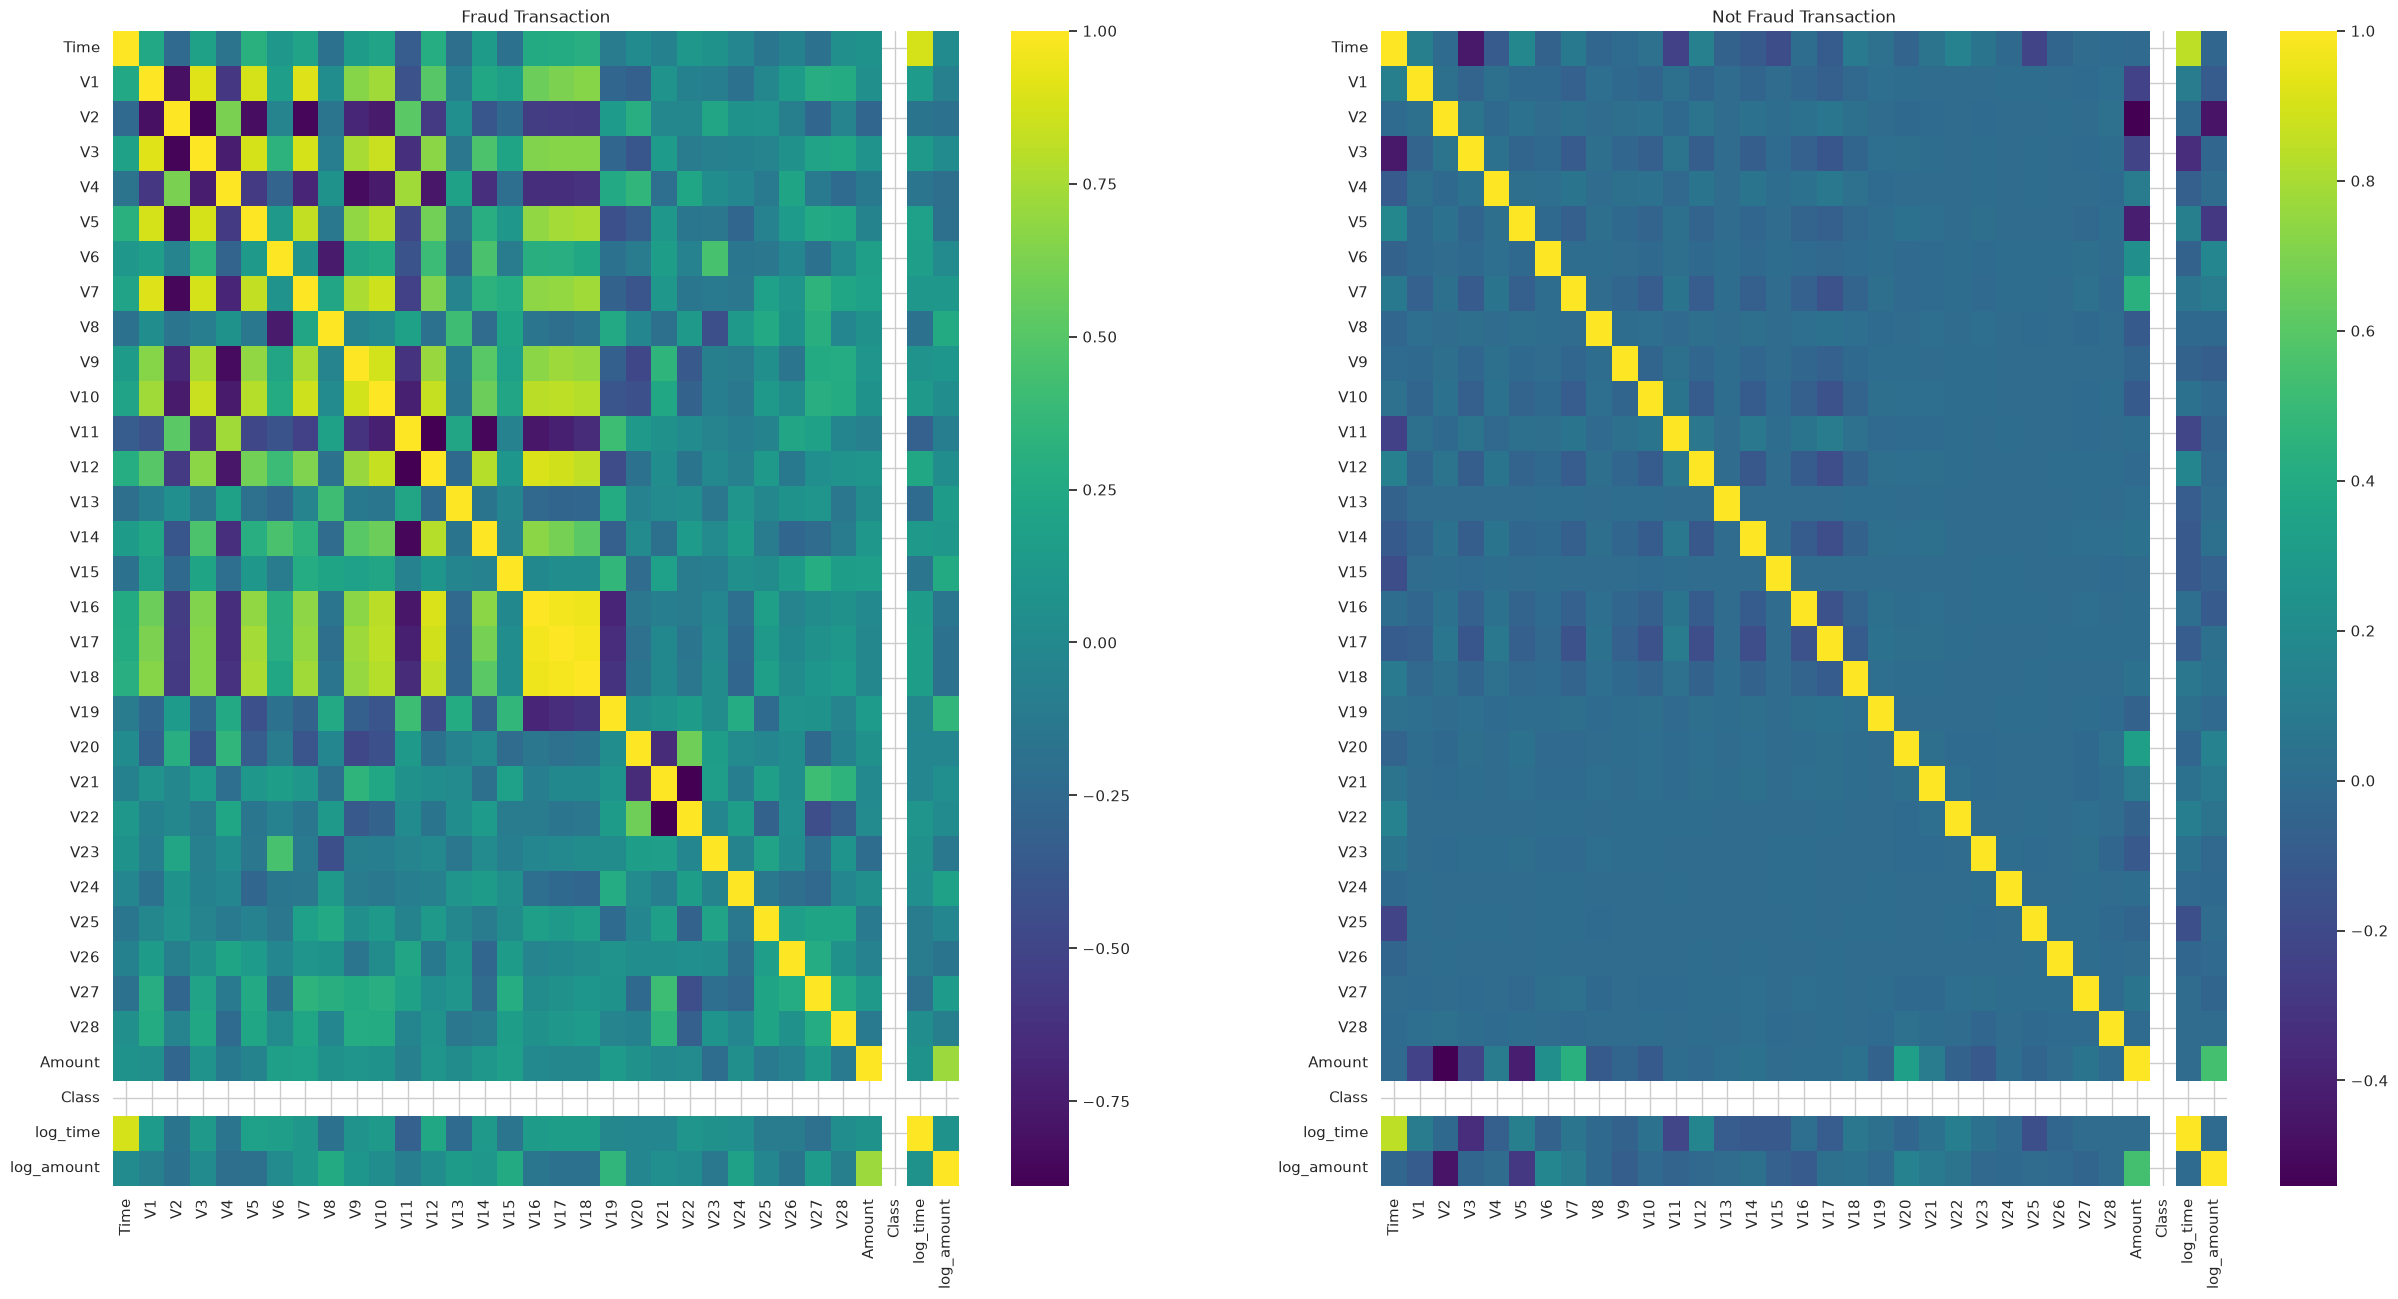

In [38]:
# plot the subplot of the fraud and normal transactions correlation matrix separately

fraud_transaction = df[df['Class'] == 1]
not_fraud_transaction = df[df['Class'] == 0]

f = plt.figure(figsize=(30, 15))
plt.subplot(1, 2, 1)
sns.heatmap(fraud_transaction.corr(), cmap='viridis', annot=False)
plt.title('Fraud Transaction')
plt.subplot(1, 2, 2)
sns.heatmap(not_fraud_transaction.corr(), cmap='viridis', annot=False)
plt.title('Not Fraud Transaction')
plt.show()

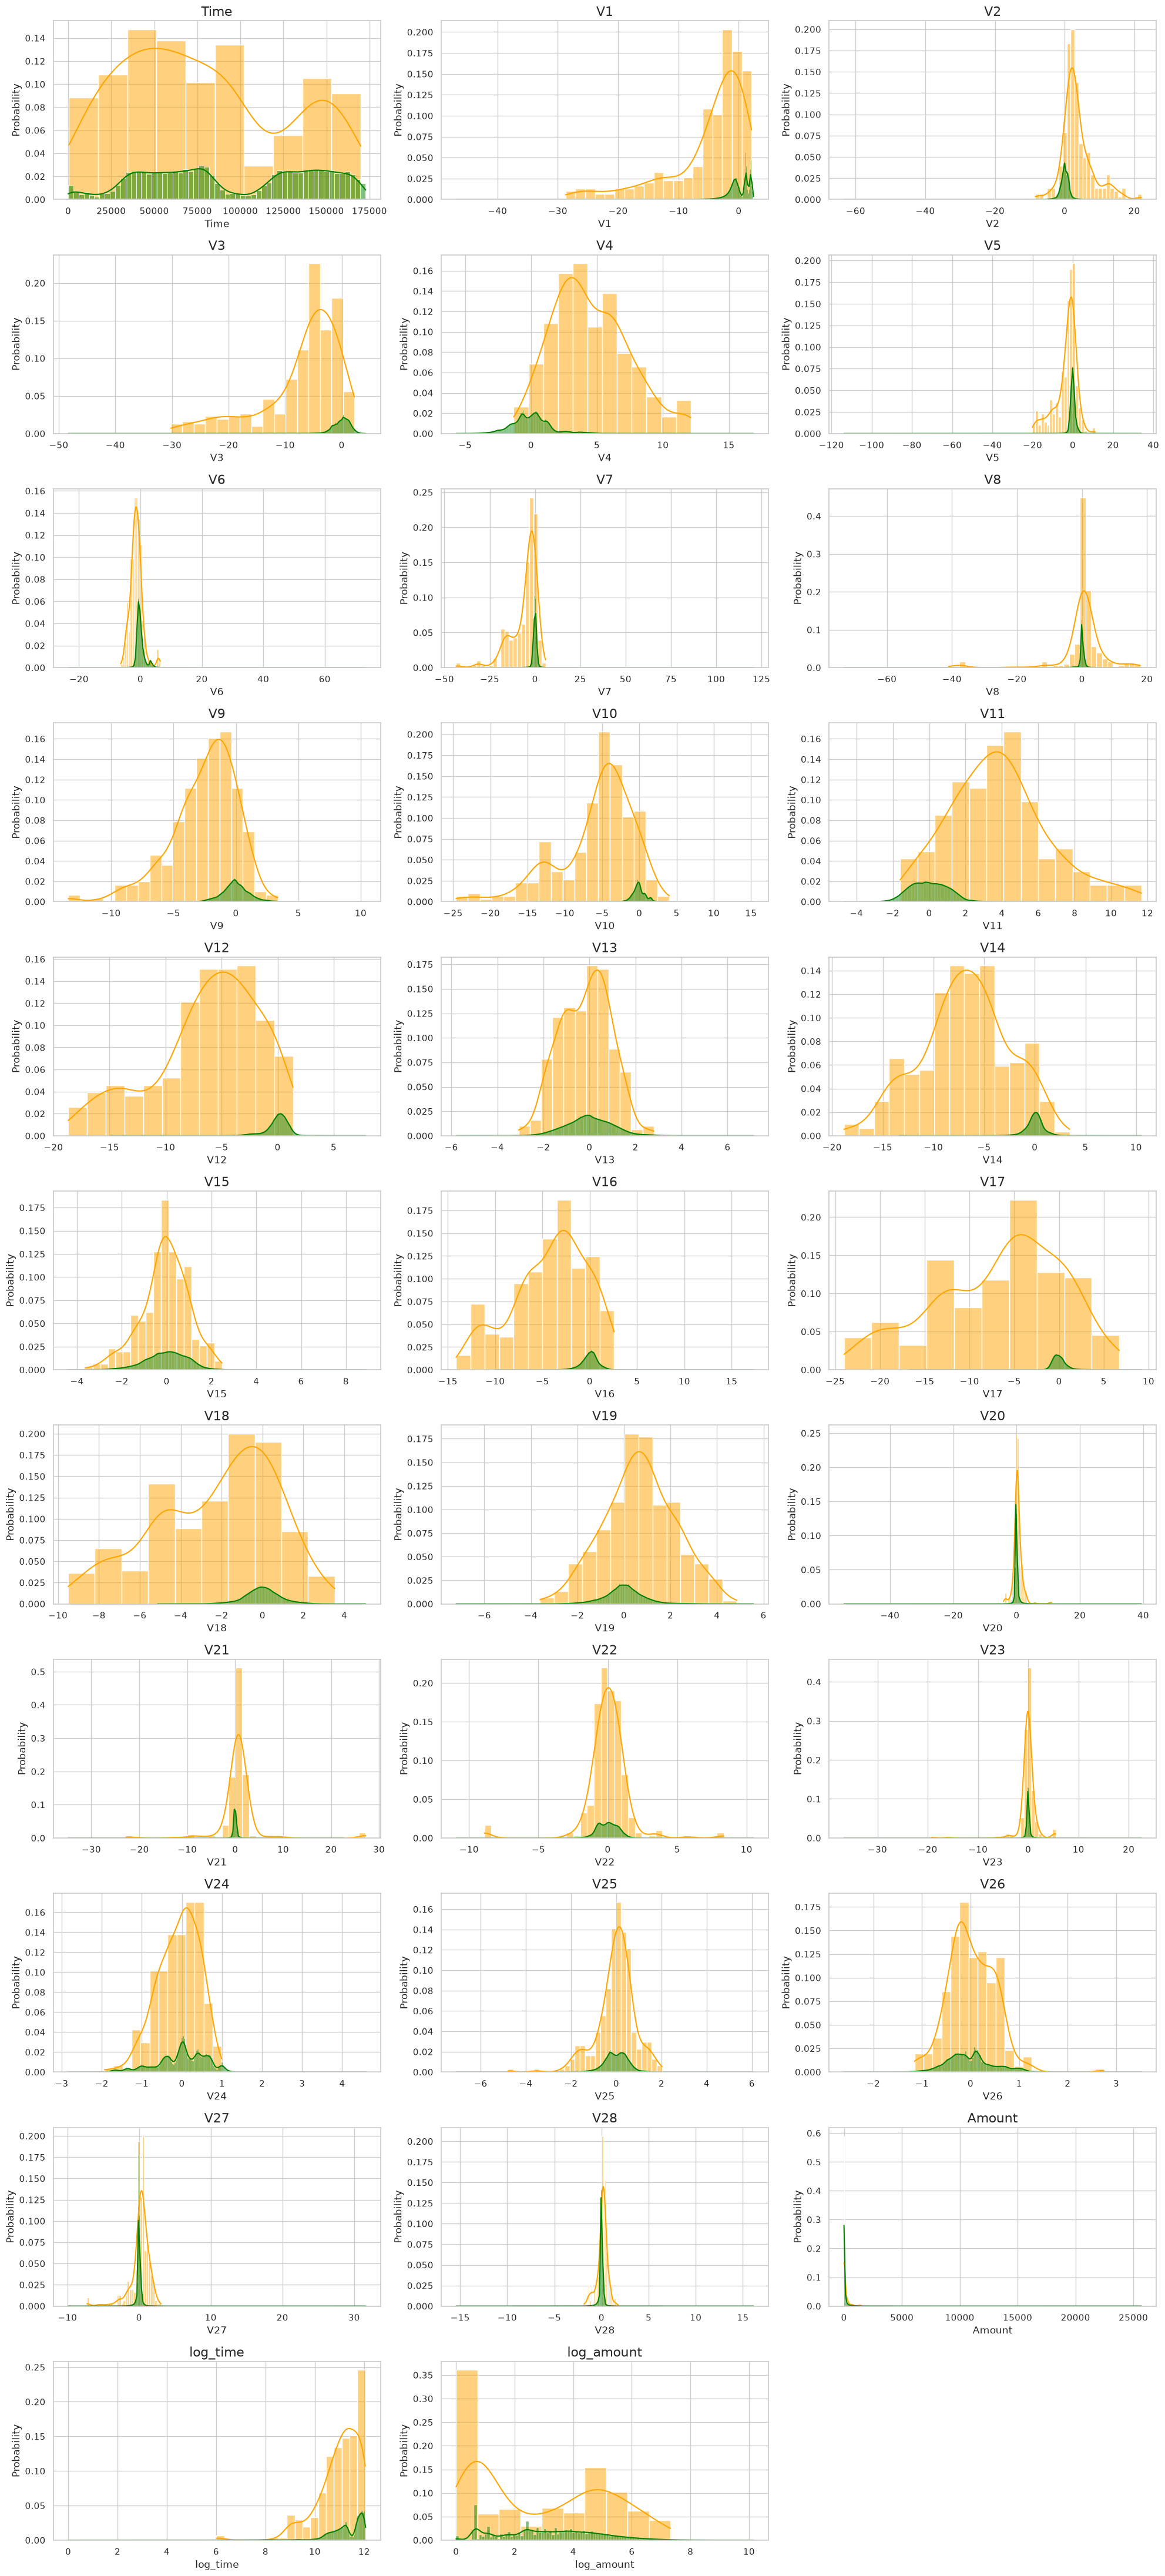

In [41]:
# 1. Filter out 'Class' first
feature_cols = [col for col in df.columns if col != 'Class']

# 2. Adjust subplot rows dynamically based on feature count
num_features = len(feature_cols)
cols_per_row = 3
rows = (num_features + cols_per_row - 1) // cols_per_row  # Auto-calculates required rows

figure = plt.figure(figsize=(20, 4 * rows))

# 3. Loop over the filtered list using correct 1-based indexing
for idx, col in enumerate(feature_cols, 1):
    plt.subplot(rows, cols_per_row, idx)
    sns.histplot(df[col][fraud_records], color='orange', label='Fraud', stat='probability', kde=True, fill=True, alpha=0.5)
    sns.histplot(df[col][unfraud_records], color='green', label='Non-Fraud', stat='probability', kde=True, fill=True, alpha=0.5)
    plt.title(col, fontsize=16)

plt.tight_layout()
plt.show()

According to distributions above:

Time: Both classes are somewhat evenly distributed, with fraud transactions peaking earlier than non-fraud.

V1 to V28: The distributions vary significantly between fraud and non-fraud transactions.

Amount: Non-fraud transactions show a higher density for smaller amounts, while fraud transactions have a broader spread.

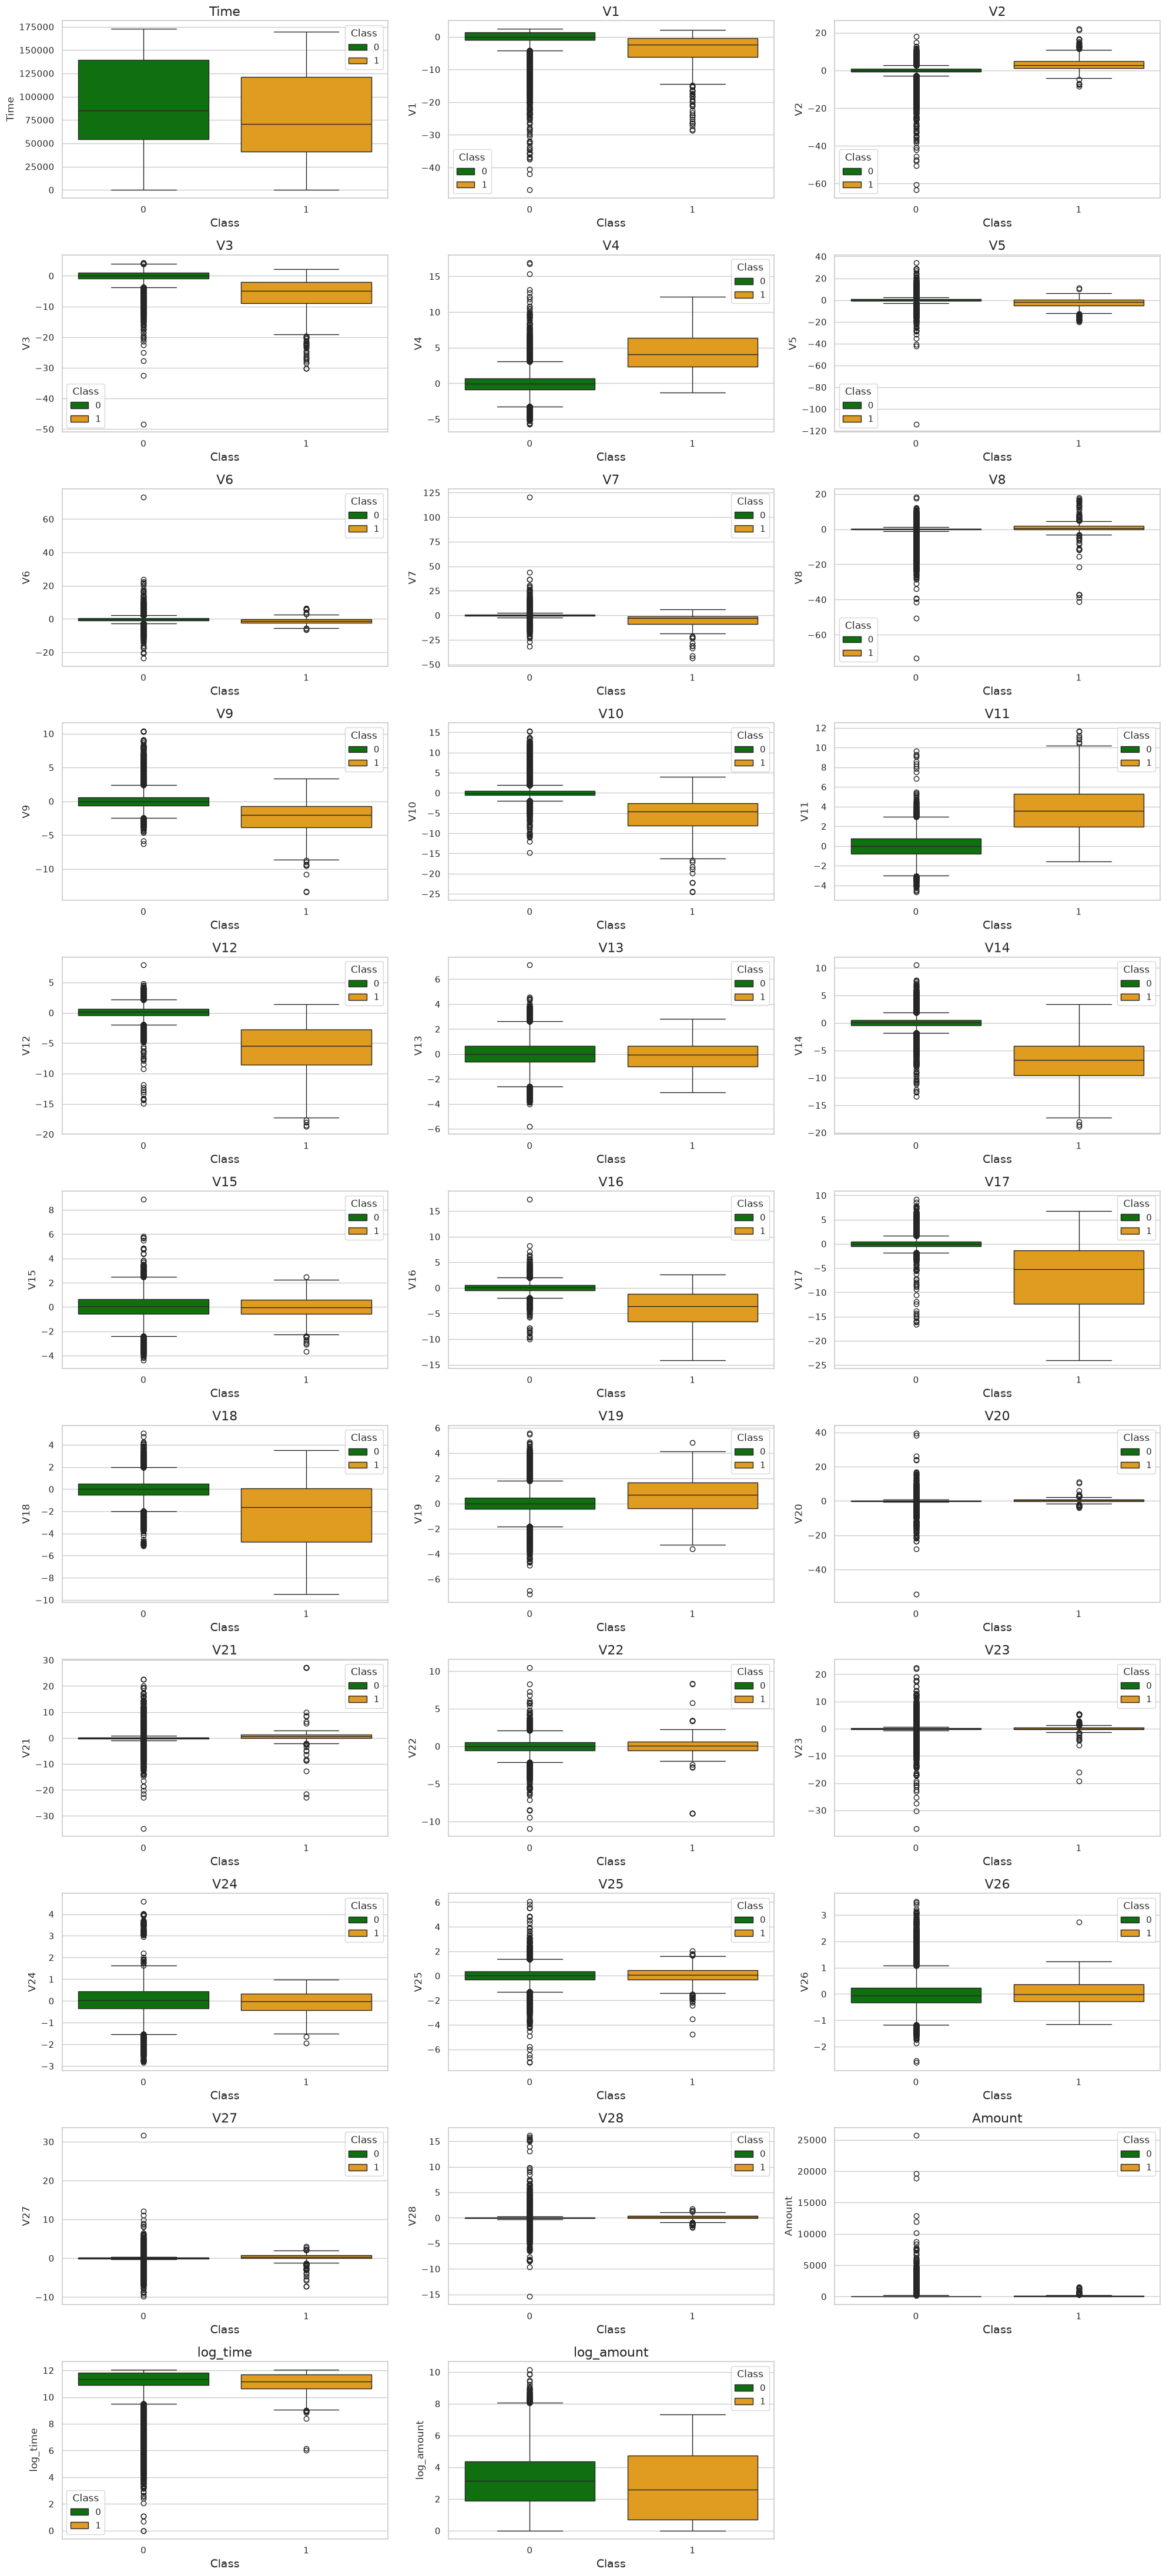

In [45]:
# 1. Filter out 'Class' first
feature_cols = [col for col in df.columns if col != 'Class']

# 2. Dynamically calculate required grid rows
num_features = len(feature_cols)
cols_per_row = 3
rows = (num_features + cols_per_row - 1) // cols_per_row

figure = plt.figure(figsize=(20, 4 * rows))

# 3. Loop over feature_cols using enumerate starting at index 1
for idx, col in enumerate(feature_cols, 1):
    plt.subplot(rows, cols_per_row, idx)
    sns.boxplot(x='Class', y=col, data=df, hue='Class', palette=['green', 'orange'])
    plt.title(col, fontsize=16)
    plt.xlabel('Class', fontsize=14)

plt.tight_layout()
plt.show()